# HW13: Tokenization, Pretrained Inference, and Fine-tuning (emotion)

In [1]:
import os
import random
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Python executable: {os.sys.executable}")
print(f"torch: {torch.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


Device: cpu
Python executable: C:\Users\artem\aie-course\Chernoskutov_AIE_Repos\homeworks\HW13\.venv\Scripts\python.exe
torch: 2.11.0+cpu
pandas: 3.0.2
numpy: 2.4.4


In [2]:
dataset = load_dataset('emotion')
label_names = dataset['train'].features['label'].names
num_labels = len(label_names)

split_sizes = {split: len(dataset[split]) for split in dataset.keys()}
print('Split sizes:', split_sizes)
print('Label names:', label_names)

pd.DataFrame([
    {'split': k, 'size': v} for k, v in split_sizes.items()
])


Split sizes: {'train': 16000, 'validation': 2000, 'test': 2000}
Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,split,size
0,train,16000
1,validation,2000
2,test,2000


In [3]:
example_ids = [0, 1, 2, 100, 1000]
rows = []
for idx in example_ids:
    item = dataset['train'][idx]
    rows.append({
        'idx': idx,
        'text': item['text'],
        'label_id': item['label'],
        'label_name': label_names[item['label']],
    })

examples_df = pd.DataFrame(rows)
print('What is being classified: short user text by one of 6 emotions.')
examples_df


What is being classified: short user text by one of 6 emotions.


,idx,text,label_id,label_name
0,0,i didnt feel humiliated,0,sadness
1,1,i can go from feeling so hopeless to so damned...,0,sadness
2,2,im grabbing a minute to post i feel greedy wrong,3,anger
3,100,i wont let me child cry it out because i feel ...,2,love
4,1000,i need to do the best i possibly can do and ev...,0,sadness


In [4]:
train_label_counts = pd.Series(dataset['train']['label']).value_counts().sort_index()
train_label_dist = pd.DataFrame({
    'label_id': train_label_counts.index,
    'label_name': [label_names[i] for i in train_label_counts.index],
    'count': train_label_counts.values,
    'share': train_label_counts.values / train_label_counts.values.sum(),
})
train_label_dist


,label_id,label_name,count,share
0,0,sadness,4666,0.291625
1,1,joy,5362,0.335125
2,2,love,1304,0.081500
3,3,anger,2159,0.134937
4,4,fear,1937,0.121063
5,5,surprise,572,0.035750


In [5]:
model_checkpoint = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

token_texts = [dataset['train'][i]['text'] for i in range(5)]
print('Tokenizer special tokens map:', tokenizer.special_tokens_map)

for i, text in enumerate(token_texts, start=1):
    encoded = tokenizer(text, add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
    print(f"\nExample {i}")
    print('text:', text)
    print('tokens:', tokens)
    print('input_ids:', encoded['input_ids'])
    print('attention_mask:', encoded['attention_mask'])

packed = tokenizer(
    token_texts,
    padding=True,
    truncation=True,
    max_length=16,
    return_tensors='pt'
)
print('\nPadding/truncation demo with max_length=16')
print('input_ids shape:', tuple(packed['input_ids'].shape))
print('attention_mask shape:', tuple(packed['attention_mask'].shape))
print('first row input_ids:', packed['input_ids'][0].tolist())
print('first row attention_mask:', packed['attention_mask'][0].tolist())


Tokenizer special tokens map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Example 1
text: i didnt feel humiliated
tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]

Example 2
text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Example 3
text: im grabbing a minute to post i feel greedy wrong
tokens: ['[CLS]', 'im', 'gra

In [6]:
pretrained_inference_model = 'distilbert-base-uncased-finetuned-sst-2-english'
clf_pipe = pipeline(
    'text-classification',
    model=pretrained_inference_model,
    tokenizer=pretrained_inference_model,
    device=0 if torch.cuda.is_available() else -1,
)

inference_ids = [0, 1, 2, 3, 4]
inference_texts = [dataset['test'][i]['text'] for i in inference_ids]
inference_true = [label_names[dataset['test'][i]['label']] for i in inference_ids]
inference_out = clf_pipe(inference_texts)

inference_df = pd.DataFrame({
    'text': inference_texts,
    'true_emotion': inference_true,
    'pretrained_label': [x['label'] for x in inference_out],
    'pretrained_score': [round(float(x['score']), 4) for x in inference_out],
})

print('Pretrained model before fine-tuning is binary sentiment (POSITIVE/NEGATIVE).')
print('It is only partially aligned with 6-class emotion task.')
inference_df


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pretrained model before fine-tuning is binary sentiment (POSITIVE/NEGATIVE).
It is only partially aligned with 6-class emotion task.


,text,true_emotion,pretrained_label,pretrained_score
0,im feeling rather rotten so im not very ambiti...,sadness,NEGATIVE,0.9998
1,im updating my blog because i feel shitty,sadness,NEGATIVE,0.9995
2,i never make her separate from me because i do...,sadness,POSITIVE,0.9993
3,i left with my bouquet of red and yellow tulip...,joy,POSITIVE,0.9868
4,i was feeling a little vain when i did this one,sadness,NEGATIVE,0.9996


In [7]:
max_length = 64

def preprocess(batch):
    return tokenizer(batch['text'], truncation=True, max_length=max_length)

tokenized = dataset.map(preprocess, batched=True)
tokenized = tokenized.remove_columns(['text'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for i, name in enumerate(label_names)}

print(tokenized)


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='artifacts/checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    seed=SEED,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best validation f1_macro:', trainer.state.best_metric)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


C:\Users\artem\aie-course\Chernoskutov_AIE_Repos\homeworks\HW13\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.501535,0.208329,0.926500,0.900894
2,0.146998,0.164816,0.935000,0.910164


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\artem\aie-course\Chernoskutov_AIE_Repos\homeworks\HW13\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].


There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Best checkpoint: artifacts/checkpoints\checkpoint-2000
Best validation f1_macro: 0.9101636397940579


In [9]:
pred_output = trainer.predict(tokenized['test'])
logits = pred_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
pred_ids = probs.argmax(axis=1)
true_ids = np.array(dataset['test']['label'])

test_accuracy = accuracy_score(true_ids, pred_ids)
test_f1_macro = f1_score(true_ids, pred_ids, average='macro')

print(f'test_accuracy: {test_accuracy:.4f}')
print(f'test_f1_macro: {test_f1_macro:.4f}')


C:\Users\artem\aie-course\Chernoskutov_AIE_Repos\homeworks\HW13\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


test_accuracy: 0.9240
test_f1_macro: 0.8787


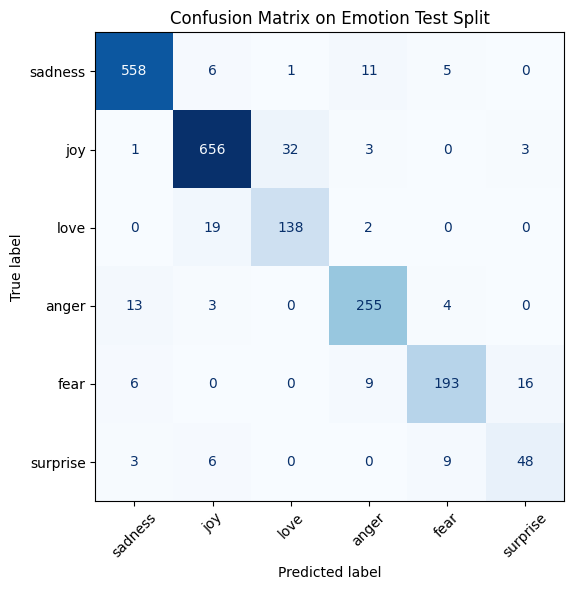

Saved: artifacts\confusion_matrix.png
Saved: artifacts/sample_predictions.csv


,text,true_label,pred_label,confidence
0,i don t feel particularly agitated,fear,anger,0.912272
1,i feel if i completely hated things i d exerci...,anger,sadness,0.501052
2,i feel i have to agree with her even though i ...,sadness,joy,0.885608
3,i feel a bit stressed even though all the thin...,anger,sadness,0.683635
4,i feel like i am in paradise kissing those swe...,joy,love,0.642698
5,i was feeling weird the other day and it went ...,fear,surprise,0.516166
6,when a friend dropped a frog down my neck,anger,fear,0.869082
7,i feel agitated with myself that i did not for...,fear,anger,0.778352
8,i looked at mabel this morning i named my left...,fear,surprise,0.569772
9,i feel is he generous,love,joy,0.661568


In [10]:
Path('artifacts').mkdir(exist_ok=True)

cm = confusion_matrix(true_ids, pred_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
plt.title('Confusion Matrix on Emotion Test Split')
plt.xticks(rotation=45)
plt.tight_layout()
cm_path = Path('artifacts/confusion_matrix.png')
fig.savefig(cm_path, dpi=200)
plt.show()

all_preds_df = pd.DataFrame({
    'text': dataset['test']['text'],
    'true_label': [label_names[i] for i in true_ids],
    'pred_label': [label_names[i] for i in pred_ids],
    'confidence': probs.max(axis=1),
})

errors_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].copy()
correct_df = all_preds_df[all_preds_df['true_label'] == all_preds_df['pred_label']].copy()

sample_predictions = pd.concat(
    [errors_df.head(10), correct_df.head(10)],
    ignore_index=True,
)
sample_predictions.to_csv('artifacts/sample_predictions.csv', index=False)

print('Saved:', cm_path)
print('Saved: artifacts/sample_predictions.csv')
sample_predictions.head(10)


In [11]:
def short_comment(true_label, pred_label, text):
    if {true_label, pred_label} == {'joy', 'love'}:
        return 'Joy and love often overlap semantically in short texts.'
    if {true_label, pred_label} == {'anger', 'sadness'}:
        return 'Negative emotion words can be ambiguous between anger and sadness.'
    if pred_label == 'surprise':
        return 'Surprise is rare; punctuation or sudden wording can trigger confusion.'
    if len(text.split()) <= 4:
        return 'Very short text gives too little context for stable emotion prediction.'
    return 'Lexical overlap between emotions likely caused the confusion.'

error_analysis = errors_df.head(8).copy()
error_analysis['comment'] = [
    short_comment(t, p, txt)
    for t, p, txt in zip(error_analysis['true_label'], error_analysis['pred_label'], error_analysis['text'])
]

print('Error examples (first 8):')
error_analysis[['text', 'true_label', 'pred_label', 'confidence', 'comment']]


Error examples (first 8):


,text,true_label,pred_label,confidence,comment
10,i don t feel particularly agitated,fear,anger,0.912272,Lexical overlap between emotions likely caused...
40,i feel if i completely hated things i d exerci...,anger,sadness,0.501052,Negative emotion words can be ambiguous betwee...
43,i feel i have to agree with her even though i ...,sadness,joy,0.885608,Lexical overlap between emotions likely caused...
67,i feel a bit stressed even though all the thin...,anger,sadness,0.683635,Negative emotion words can be ambiguous betwee...
86,i feel like i am in paradise kissing those swe...,joy,love,0.642698,Joy and love often overlap semantically in sho...
93,i was feeling weird the other day and it went ...,fear,surprise,0.516166,Surprise is rare; punctuation or sudden wordin...
94,when a friend dropped a frog down my neck,anger,fear,0.869082,Lexical overlap between emotions likely caused...
103,i feel agitated with myself that i did not for...,fear,anger,0.778352,Lexical overlap between emotions likely caused...


In [12]:
summary = {
    'dataset': 'emotion',
    'num_labels': num_labels,
    'label_names': label_names,
    'split_sizes': split_sizes,
    'model_checkpoint': model_checkpoint,
    'pretrained_inference_model': pretrained_inference_model,
    'max_length': max_length,
    'batch_size_train': training_args.per_device_train_batch_size,
    'batch_size_eval': training_args.per_device_eval_batch_size,
    'num_train_epochs': training_args.num_train_epochs,
    'learning_rate': training_args.learning_rate,
    'best_validation_f1_macro': float(trainer.state.best_metric),
    'best_checkpoint': trainer.state.best_model_checkpoint,
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(test_f1_macro),
    'device': str(device),
    'seed': SEED,
}

with open('artifacts/run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "dataset": "emotion",
  "num_labels": 6,
  "label_names": [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
  ],
  "split_sizes": {
    "train": 16000,
    "validation": 2000,
    "test": 2000
  },
  "model_checkpoint": "distilbert-base-uncased",
  "pretrained_inference_model": "distilbert-base-uncased-finetuned-sst-2-english",
  "max_length": 64,
  "batch_size_train": 16,
  "batch_size_eval": 64,
  "num_train_epochs": 2,
  "learning_rate": 2e-05,
  "best_validation_f1_macro": 0.9101636397940579,
  "best_checkpoint": "artifacts/checkpoints\\checkpoint-2000",
  "test_accuracy": 0.924,
  "test_f1_macro": 0.8786914813445672,
  "device": "cpu",
  "seed": 42
}


In [13]:
# Keep artifacts folder minimal for submission.
if Path('artifacts/checkpoints').exists():
    shutil.rmtree('artifacts/checkpoints')
    print('Removed artifacts/checkpoints to keep only minimal required artifacts.')
else:
    print('No checkpoints folder to remove.')


Removed artifacts/checkpoints to keep only minimal required artifacts.
